# Лабораторная работа 1

Machine Unlearning

## Сбор публикаций

импорт библиотек

In [1]:
import re
import time
import feedparser
import pandas as pd
import requests

формирование запроса:
- устанавливаю период в котором ищем нужные публикации
- ищу в названии статьи/аннотации machine unlearning

так же заранее завела константы которые будут использоваться дальше:
- api для запроса
- размер странцы
- минимальное значение количества собранных статей после для проверки
- время для паузы после запросов (тк в документации написано что между запросами должно быть не менее 3 секунд - https://info.arxiv.org/help/api/tou.html#rate-limits:~:text=When%20using%20the%20legacy%20APIs%20(including%20OAI%2DPMH%2C%20RSS%2C%20and%20the%20arXiv%20API)%2C%20make%20no%20more%20than%20one%20request%20every%20three%20seconds%2C%20and%20limit%20requests%20to%20a%20single%20connection%20at%20a%20time - взяла с запасом!)

In [2]:
API_URL = "https://export.arxiv.org/api/query"
DATE_FROM = "2020-01-01T00:00:00Z"
DATE_TO = "2026-09-20T21:47:00Z"
MIN_PUBLICATIONS = 300
PAGE_SIZE = 100
REQUEST_PAUSE = 3.3

start_time = pd.Timestamp(DATE_FROM)
end_time = pd.Timestamp(DATE_TO)
SEARCH_QUERY = (
    '(ti:"machine unlearning" OR abs:"machine unlearning") '
    f'AND submittedDate:[{start_time.strftime("%Y%m%d%H%M")} '
    f'TO {end_time.strftime("%Y%m%d%H%M")}]'
)

выгрузка статей

arXiv дает ответ в формате Atom/XML (в отличие от OpenAlex - там ответ в формате json), поэтому необходимо использовать feedparser.parse()

ниже описана функция, которая получает только 1 страницу - в ячейке после нее в цикле получаю нужно количество статей


In [3]:
def fetch_page(start):
    params = {
        "search_query": SEARCH_QUERY,
        "start": start,
        "max_results": PAGE_SIZE,
        "sortBy": "submittedDate",
        "sortOrder": "ascending",
    }
    time.sleep(REQUEST_PAUSE)
    response = requests.get(API_URL, params=params, timeout=60)
    response.raise_for_status()
    feed = feedparser.parse(response.content)
    total = int(feed.feed["opensearch_totalresults"])
    return feed.entries, total


In [4]:
records = []
start = 0
total = None
raw_df = df = None

while total is None or start < total:
    entries, page_total = fetch_page(start)
    if total is None:
        total = page_total
        if total < MIN_PUBLICATIONS:
            raise ValueError("найдено меньше 300 работ")

    for entry in entries:
        version_id = entry.get("id", "").rstrip("/").rsplit("/", 1)[-1]
        arxiv_id = re.sub(r"v\d+$", "", version_id)
        records.append({
            "arxiv_id": arxiv_id,
            "version_id": version_id,
            "title": entry.get("title", ""),
            "authors": [author.get("name", "") for author in entry.get("authors", [])],
            "abstract": entry.get("summary", ""),
            "published": entry.get("published", ""),
            "updated": entry.get("updated", ""),
            "url": f"https://arxiv.org/abs/{arxiv_id}",
            "categories": [tag.get("term", "") for tag in entry.get("tags", [])],
        })

    start += len(entries)
    print(f"получено {len(records)} / {total}")


получено 100 / 856
получено 200 / 856
получено 300 / 856
получено 400 / 856
получено 500 / 856
получено 600 / 856
получено 700 / 856
получено 800 / 856
получено 856 / 856


подготовка и проверка таблицы

нужно:
- исправить пробелы/переносы
- перевести даты в UTC
- удалить неполные записи
- удалить статьи вне периода
- не должно быть дублей одной и той же статьи

In [5]:
raw_df = pd.DataFrame(records)
df = raw_df.copy()

def compact_spaces(text):
    return " ".join(str(text or "").split())

for column in ("title", "abstract"):
    df[column] = df[column].map(compact_spaces)
df["authors"] = df["authors"].map(
    lambda names: [compact_spaces(name) for name in names if compact_spaces(name)]
)
for column in ("published", "updated"):
    df[column] = pd.to_datetime(df[column], utc=True, errors="coerce")

valid = (
    df["arxiv_id"].str.fullmatch(r"\d{4}\.\d{4,5}")
    & df["title"].ne("")
    & df["abstract"].ne("")
    & df["authors"].map(len).gt(0)
    & df["published"].between(start_time, end_time)
)
df = (
    df.loc[valid]
    .sort_values(["updated", "version_id"], na_position="first")
    .drop_duplicates("arxiv_id", keep="last")
    .sort_values(["published", "arxiv_id"])
    .reset_index(drop=True)
)
print(f"получено: {len(raw_df)}; исключено: {len(raw_df) - len(df)}; осталось: {len(df)}.")

получено: 856; исключено: 0; осталось: 856.


In [6]:
assert len(df) >= MIN_PUBLICATIONS, "меньше 300 публикаций"
assert df["arxiv_id"].is_unique, "есть повторные ID"
assert df["title"].str.strip().ne("").all(), "есть пустые названия"
assert df["abstract"].str.strip().ne("").all(), "есть пустые аннотации"
assert df["authors"].map(lambda names: bool(names) and all(names)).all(), "не заполнены авторы"
assert df["published"].between(start_time, end_time).all(), "есть даты вне периода"
print("все хорошо:)")

все хорошо:)


и пример что собралось

In [7]:
display(df[["title", "published", "url"]].sample(5, random_state=42))
print(
    f"уникальных публикаций: {len(df)}\n"
    f"даты публикаций: {df['published'].min().date()} — "f"{df['published'].max().date()}\n"
)

,title,published,url
711,From Anchors to Supervision: Memory-Graph Guid...,2026-04-15 12:07:14+00:00,https://arxiv.org/abs/2604.13777
603,Forget-It-All: Multi-Concept Machine Unlearnin...,2026-01-07 00:13:36+00:00,https://arxiv.org/abs/2601.06163
120,Layer Attack Unlearning: Fast and Accurate Mac...,2023-12-28 04:38:06+00:00,https://arxiv.org/abs/2312.16823
208,Recent Advances in Federated Learning Driven L...,2024-06-14 08:40:58+00:00,https://arxiv.org/abs/2406.09831
380,Benchmarking Federated Machine Unlearning meth...,2025-04-01 15:53:36+00:00,https://arxiv.org/abs/2504.00921


уникальных публикаций: 856
даты публикаций: 2020-02-07 — 2026-09-18



## Разведочный анализ

токенизацию повторила как в лекции: нижний регистр и последовательности английских букв [a-z]+ - ровно по этой причине model и models пока разные слова, model-based разбивается на два токена, стоп-слова сохраняю для длин и Ципфа - исключаю их только из второго топ-20


In [8]:
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from IPython.display import Markdown

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

eda_df = df.copy(deep=True)
eda_df["year"] = eda_df["published"].dt.year
eda_df["title_tokens"] = eda_df["title"].fillna("").map(tokenize)
eda_df["abstract_tokens"] = eda_df["abstract"].fillna("").map(tokenize)
eda_df["title_length"] = eda_df["title_tokens"].map(len)
eda_df["abstract_length"] = eda_df["abstract_tokens"].map(len)
eda_df["tokens"] = eda_df["title_tokens"] + eda_df["abstract_tokens"]

zero_tokens = eda_df["tokens"].map(len).eq(0)
print(f"документов без буквенных токенов: {zero_tokens.sum()}. строки не удаляю.")
if zero_tokens.any():
    display(eda_df.loc[zero_tokens, ["arxiv_id", "title", "url"]].head(5))


документов без буквенных токенов: 0. строки не удаляю.


### Паспорт корпуса

для сравнения текстов привожу их к нижнему регистру и одинаковым пробелам

число повторов — количество строк сверх первой в каждой группе одинаковых значений

In [9]:
normalized_titles = eda_df["title"].fillna("").str.lower().str.split().str.join(" ")
normalized_abstracts = eda_df["abstract"].fillna("").str.lower().str.split().str.join(" ")
missing_authors = eda_df["authors"].map(
    lambda names: not isinstance(names, list)
    or not any(isinstance(name, str) and name.strip() for name in names)
)
corpus_summary = pd.DataFrame({
    "показатель": [
        "Публикаций", "Первая дата", "Последняя дата",
        "Пустых названий", "Пустых аннотаций", "Не заполнены авторы",
        "Повторных ID", "Повторных названий", "Повторных аннотаций",
    ],
    "значение": [
        len(eda_df), str(eda_df["published"].min().date()), str(eda_df["published"].max().date()),
        int(normalized_titles.eq("").sum()), int(normalized_abstracts.eq("").sum()),
        int(missing_authors.sum()), int(eda_df["arxiv_id"].duplicated().sum()),
        int(normalized_titles.duplicated().sum()), int(normalized_abstracts.duplicated().sum()),
    ],
})
display(corpus_summary)

repeated_texts = normalized_titles.duplicated(keep=False) | normalized_abstracts.duplicated(keep=False)
if repeated_texts.any():
    print("примеры публикаций с повторяющимися названиями или аннотациями:")
    display(eda_df.loc[repeated_texts, ["arxiv_id", "title", "url"]].head(5))


,показатель,значение
0,Публикаций,856
1,Первая дата,2020-02-07
2,Последняя дата,2026-09-18
3,Пустых названий,0
4,Пустых аннотаций,0
5,Не заполнены авторы,0
6,Повторных ID,0
7,Повторных названий,2
8,Повторных аннотаций,1


примеры публикаций с повторяющимися названиями или аннотациями:


,arxiv_id,title,url
134,2404.16841,Machine Unlearning in Large Language Models,https://arxiv.org/abs/2404.16841
184,2405.15152,Machine Unlearning in Large Language Models,https://arxiv.org/abs/2405.15152
385,2504.06407,Understanding Machine Unlearning Through the L...,https://arxiv.org/abs/2504.06407
815,2607.23970,Understanding Machine Unlearning Through the L...,https://arxiv.org/abs/2607.23970


публикации по годам

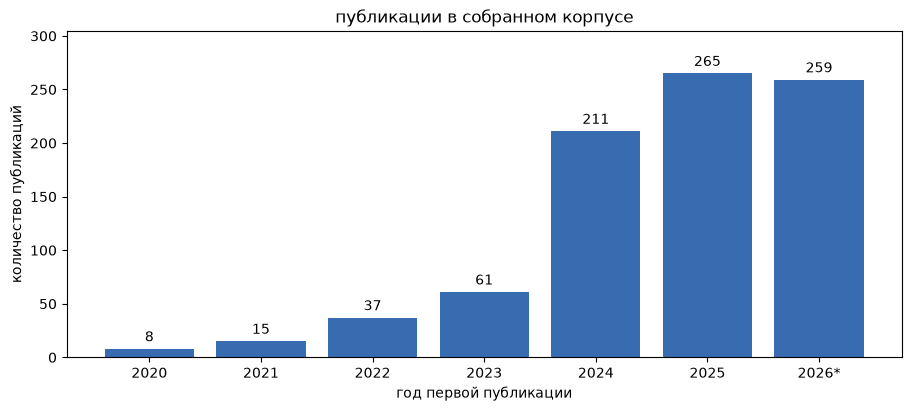

больше всего работ в выборке за 2025: 265.
граница выборки: 20.09.2026 21:47 UTC.


In [10]:
first_year = pd.Timestamp(DATE_FROM).year
cutoff = pd.Timestamp(DATE_TO)
year_counts = eda_df["year"].value_counts().reindex(
    range(first_year, cutoff.year + 1), fill_value=0
).sort_index()
last_year_end = pd.Timestamp(f"{cutoff.year + 1}-01-01", tz="UTC") - pd.Timedelta(minutes=1)
partial_last_year = cutoff < last_year_end

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
bars = ax.bar(year_counts.index, year_counts.values, color="#386CB0")
ax.bar_label(bars, padding=3)
ax.set_xticks(year_counts.index, [
    f"{year}*" if partial_last_year and year == cutoff.year else str(year)
    for year in year_counts.index
])
ax.set(title="публикации в собранном корпусе", xlabel="год первой публикации",
       ylabel="количество публикаций", ylim=(0, max(1, year_counts.max()) * 1.15))
plt.show()

peak_years = ", ".join(map(str, year_counts.index[year_counts.eq(year_counts.max())]))
print(f"больше всего работ в выборке за {peak_years}: {year_counts.max()}.")
print(f"граница выборки: {cutoff.strftime('%d.%m.%Y %H:%M UTC')}.")

длины названий и аннотаций

медиана показывает типичную длину, квартили описывают разброс

,"Название, токены","Аннотация, токены"
Минимум,2.0,82.0
Первый квартиль,7.0,163.8
Медиана,9.5,193.0
Среднее,9.5,193.4
Третий квартиль,12.0,222.0
Максимум,21.0,304.0


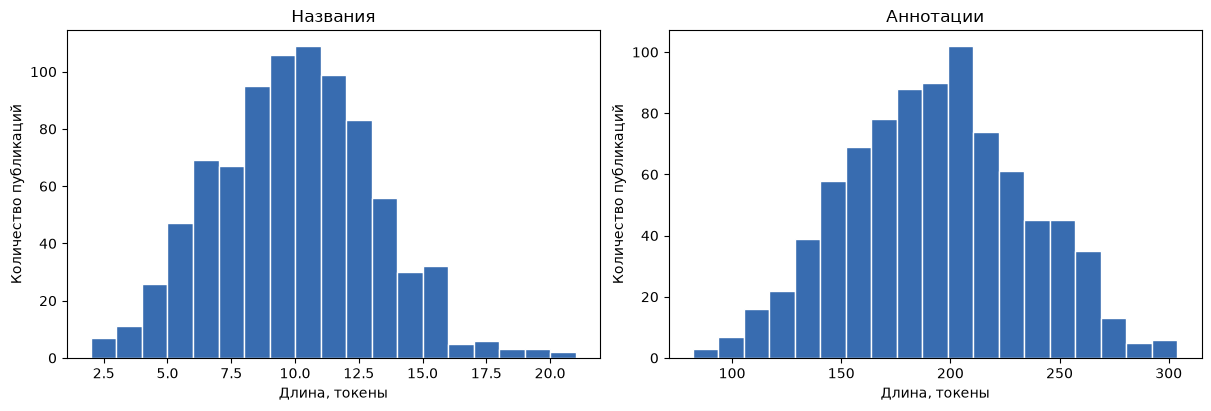

три самые короткие аннотации


,title,abstract_length,url
500,Analise de Desaprendizado de Maquina em Modelo...,82,https://arxiv.org/abs/2508.18509
504,Unleashing Uncertainty: Efficient Machine Unle...,85,https://arxiv.org/abs/2508.20773
12,A unified PAC-Bayesian framework for machine u...,93,https://arxiv.org/abs/2106.00265


три самые длинные аннотации


,title,abstract_length,url
111,Machine Unlearning in Learned Databases: An Ex...,304,https://arxiv.org/abs/2311.17276
23,Zero-Shot Machine Unlearning,299,https://arxiv.org/abs/2201.05629
20,Fast Yet Effective Machine Unlearning,298,https://arxiv.org/abs/2111.08947


In [11]:
length_stats = eda_df[["title_length", "abstract_length"]].describe().loc[
    ["min", "25%", "50%", "mean", "75%", "max"]
].rename(
    index={"min": "Минимум", "25%": "Первый квартиль", "50%": "Медиана",
           "mean": "Среднее", "75%": "Третий квартиль", "max": "Максимум"},
    columns={"title_length": "Название, токены", "abstract_length": "Аннотация, токены"},
)
display(length_stats.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, column, title in zip(axes, ["title_length", "abstract_length"], ["Названия", "Аннотации"]):
    ax.hist(eda_df[column], bins="auto", color="#386CB0", edgecolor="white")
    ax.set(title=title, xlabel="Длина, токены", ylabel="Количество публикаций")
plt.show()

for label, sample in [
    ("три самые короткие аннотации", eda_df.nsmallest(3, "abstract_length")),
    ("три самые длинные аннотации", eda_df.nlargest(3, "abstract_length")),
]:
    print(label)
    display(sample[["title", "abstract_length", "url"]])


частоты слов

корпусная частота — сколько раз слово встретилось во всех названиях и аннотациях

документная частота — в скольких статьях оно есть хотя бы один раз

N — число всех токенов, V — число различных токенов

Слова с частотой 1 называются hapax legomena - их долю считаю именно среди различных слов, а не среди всех вхождений

для второго топ-20 беру готовый ENGLISH_STOP_WORDS из scikit-learn без собственных дополнений


In [12]:
word_counts = Counter()
document_counts = Counter()
for tokens in eda_df["tokens"]:
    word_counts.update(tokens)
    document_counts.update(set(tokens))

word_stats = pd.DataFrame([
    {"word": word, "frequency": frequency, "document_frequency": document_counts[word]}
    for word, frequency in word_counts.items()
]).sort_values(["frequency", "word"], ascending=[False, True]).reset_index(drop=True)
word_stats["rank"] = range(1, len(word_stats) + 1)

n_tokens = sum(word_counts.values())
vocabulary_size = len(word_counts)
hapax_count = int(word_stats["frequency"].eq(1).sum())
display(pd.DataFrame({
    "показатель": ["Всего токенов N", "Различных слов V", "Слов с частотой 1", "Их доля среди V, %"],
    "значение": [n_tokens, vocabulary_size, hapax_count, round(100 * hapax_count / vocabulary_size, 1)],
}))
display(word_stats.head(10))


,показатель,значение
0,Всего токенов N,173662.0
1,Различных слов V,8289.0
2,Слов с частотой 1,2710.0
3,"Их доля среди V, %",32.7


,word,frequency,document_frequency,rank
0,the,7393,850,1
1,unlearning,4989,856,2
2,to,4563,852,3
3,and,4479,846,4
4,of,3992,828,5
5,a,3642,844,6
6,in,2660,808,7
7,we,2262,822,8
8,data,2154,670,9
9,for,2062,757,10


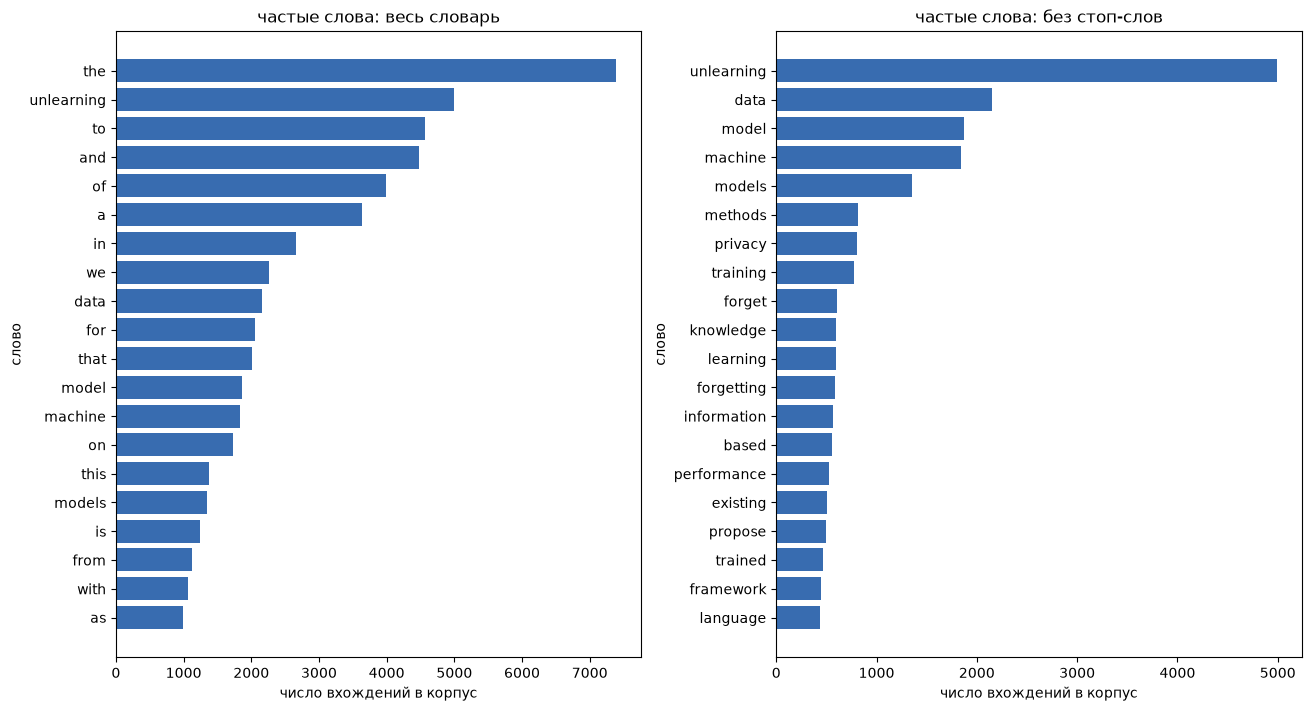

In [13]:
top_words = word_stats.head(20)
content_words = word_stats.loc[~word_stats["word"].isin(ENGLISH_STOP_WORDS)]
top_content = content_words.head(20)

fig, axes = plt.subplots(1, 2, figsize=(13, 7), layout="constrained")
for ax, table, title in zip(
    axes, [top_words, top_content], ["частые слова: весь словарь", "частые слова: без стоп-слов"]
):
    if table.empty:
        ax.text(0.5, 0.5, "после удаления стоп-слов\nне осталось токенов",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_yticks([])
    else:
        ax.barh(table["word"], table["frequency"], color="#386CB0")
        ax.invert_yaxis()
    ax.set(title=title, xlabel="число вхождений в корпус", ylabel="слово")
plt.show()

проверка закона Ципфа

ранг r — место слова в списке по убыванию частоты, начиная с 1

закон Ципфа описывает приблизительную зависимость:

$$f(r) \approx \frac{C}{r^s}, \qquad s \approx 1.$$

на log-log графике степенная зависимость выглядит примерно прямой: $\log f(r) \approx \log C - s\log r$

Строю распределение по всему базовому словарю: со стоп-словами, без лемматизации и удаления редких слов. Для сравнения добавляю f(1)/r — ориентир с s = 1, привязанный к самому частому слову, а не подобранную модель


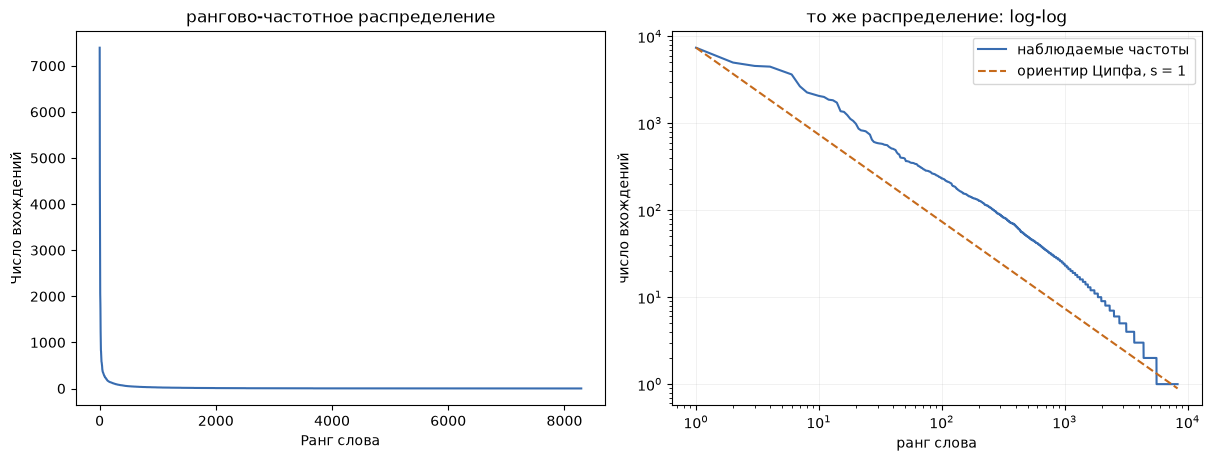

на графике 8289 слов, частота первого — 7393.
ступень частоты 1: ранги 5580–8289, всего 2710 слов


In [14]:
ranks = word_stats["rank"]
frequencies = word_stats["frequency"]
zipf_reference = frequencies.iloc[0] / ranks
point_marker = "o" if vocabulary_size == 1 else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
axes[0].plot(ranks, frequencies, color="#386CB0", linewidth=1.5, marker=point_marker)
axes[0].set(title="рангово-частотное распределение", xlabel="Ранг слова", ylabel="Число вхождений")
axes[1].loglog(ranks, frequencies, color="#386CB0", linewidth=1.5, marker=point_marker, label="наблюдаемые частоты")
axes[1].loglog(ranks, zipf_reference, "--", color="#C66A1B", label="ориентир Ципфа, s = 1")
axes[1].set(title="то же распределение: log-log", xlabel="ранг слова", ylabel="число вхождений")
axes[1].legend()
axes[1].grid(alpha=0.25, which="major")
plt.show()

print(f"на графике {vocabulary_size} слов, частота первого — {frequencies.iloc[0]}.")
if hapax_count:
    first_hapax_rank = int(word_stats.loc[word_stats["frequency"].eq(1), "rank"].iloc[0])
    print(f"ступень частоты 1: ранги {first_hapax_rank}–{vocabulary_size}, всего {hapax_count} слов")


### что видно на полученных графиках

- в выборке число публикаций увеличивается от 2020 до 2025 года - особенно заметен переход от 2023 к 2024 году, но столбец 2026 года относится только к части года - меньшая высота по сравнению с 2025 годом не доказывает снижение интереса к теме - пока еще могут быть загружены новые исследования, для точного сравнения стоит выбирать уже полностью прошедшие года
- названия сосредоточены около 10 токенов, аннотации — около 190–200, среднее и медиана длины аннотаций близки. Короткие и длинные тексты встречаются реже, но сама длина не означает ошибку данных
- в общем топе много служебных слов, например the, to, and, а без стоп-слов заметнее data, model, privacy, training, при этом model и models занимают разные позиции - формы пока не объединены. Частоты machine и unlearning зависят и от поисковой фразы, поэтому их нельзя трактовать как независимое открытие анализа
- на обычных осях видны резкое падение частот и длинный хвост. На log-log графике часть средних рангов близка к прямой, но весь график изгибается и на большей части диапазона проходит выше ориентира f(1)/r. То есть видна приблизительная рангово-частотная закономерность, а не точное выполнение закона с s = 1. Ступени в хвосте возникают из-за одинаковых целых частот, последняя ступень соответствует словам, встретившимся один раз
